In [2]:
import json
from pathlib import Path

DATA_PATH = Path("../data/otto-recsys-train.jsonl")

In [3]:
with open(DATA_PATH, "r") as f:
    first_line = f.readline()

first_session = json.loads(first_line)

first_session

{'session': 0,
 'events': [{'aid': 1517085, 'ts': 1659304800025, 'type': 'clicks'},
  {'aid': 1563459, 'ts': 1659304904511, 'type': 'clicks'},
  {'aid': 1309446, 'ts': 1659367439426, 'type': 'clicks'},
  {'aid': 16246, 'ts': 1659367719997, 'type': 'clicks'},
  {'aid': 1781822, 'ts': 1659367871344, 'type': 'clicks'},
  {'aid': 1152674, 'ts': 1659367885796, 'type': 'clicks'},
  {'aid': 1649869, 'ts': 1659369893840, 'type': 'carts'},
  {'aid': 461689, 'ts': 1659369898050, 'type': 'carts'},
  {'aid': 305831, 'ts': 1659370027105, 'type': 'orders'},
  {'aid': 461689, 'ts': 1659370027105, 'type': 'orders'},
  {'aid': 362233, 'ts': 1659370064916, 'type': 'clicks'},
  {'aid': 1649869, 'ts': 1659370067686, 'type': 'clicks'},
  {'aid': 1649869, 'ts': 1659371003682, 'type': 'clicks'},
  {'aid': 984597, 'ts': 1659371033243, 'type': 'clicks'},
  {'aid': 1649869, 'ts': 1659371042297, 'type': 'clicks'},
  {'aid': 803544, 'ts': 1659371044075, 'type': 'clicks'},
  {'aid': 1110941, 'ts': 1659371104329, '

In [4]:
first_session.keys()

dict_keys(['session', 'events'])

In [5]:
first_session['session'], len(first_session['events'])

(0, 276)

In [6]:
first_session['events'][:5]

[{'aid': 1517085, 'ts': 1659304800025, 'type': 'clicks'},
 {'aid': 1563459, 'ts': 1659304904511, 'type': 'clicks'},
 {'aid': 1309446, 'ts': 1659367439426, 'type': 'clicks'},
 {'aid': 16246, 'ts': 1659367719997, 'type': 'clicks'},
 {'aid': 1781822, 'ts': 1659367871344, 'type': 'clicks'}]

In [7]:
import pandas as pd

pd.to_datetime(
    first_session['events'][0]['ts'],
    unit='ms'
)

Timestamp('2022-07-31 22:00:00.025000')

In [8]:
first_session['events'][0]

{'aid': 1517085, 'ts': 1659304800025, 'type': 'clicks'}

In [9]:
import pandas as pd

df = pd.read_json(
    DATA_PATH,
    lines=True,
    nrows=10_000
)

df.head()

,session,events
0,0,"[{'aid': 1517085, 'ts': 1659304800025, 'type':..."
1,1,"[{'aid': 424964, 'ts': 1659304800025, 'type': ..."
2,2,"[{'aid': 763743, 'ts': 1659304800038, 'type': ..."
3,3,"[{'aid': 1425967, 'ts': 1659304800095, 'type':..."
4,4,"[{'aid': 613619, 'ts': 1659304800119, 'type': ..."


In [10]:
# Превращаем вложенные events в обычные строки таблицы
events_df = df.explode('events')

events_df.head()

,session,events
0,0,"{'aid': 1517085, 'ts': 1659304800025, 'type': ..."
0,0,"{'aid': 1563459, 'ts': 1659304904511, 'type': ..."
0,0,"{'aid': 1309446, 'ts': 1659367439426, 'type': ..."
0,0,"{'aid': 16246, 'ts': 1659367719997, 'type': 'c..."
0,0,"{'aid': 1781822, 'ts': 1659367871344, 'type': ..."


In [11]:
events_details = pd.json_normalize(events_df['events'])

events_details.head()

,aid,ts,type
0,1517085,1659304800025,clicks
0,1563459,1659304904511,clicks
0,1309446,1659367439426,clicks
0,16246,1659367719997,clicks
0,1781822,1659367871344,clicks


In [12]:
events_df.index[:10]

Index([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype='int64')

In [13]:
events_details.index[:10]

Index([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype='int64')

In [14]:
events_df = events_df.reset_index(drop=True)
events_details = events_details.reset_index(drop=True)

events = pd.concat(
    [
        events_df[['session']],
        events_details
    ],
    axis=1
)

events.head()

,session,aid,ts,type
0,0,1517085,1659304800025,clicks
1,0,1563459,1659304904511,clicks
2,0,1309446,1659367439426,clicks
3,0,16246,1659367719997,clicks
4,0,1781822,1659367871344,clicks


# Проверка качества и структуры данных

In [15]:
events.shape

(628747, 4)

In [16]:
events.dtypes

session    int64
aid        int64
ts         int64
type         str
dtype: object

Проверим данные на пропуски.

In [17]:
events.isna().sum()

session    0
aid        0
ts         0
type       0
dtype: int64

Проверим данные на наличие полных дубликатов.

In [18]:
events.duplicated().sum()

np.int64(656)

656 / 628747 ≈ 0.10%

Проверим возможные значения типов событий.

In [19]:
events['type'].value_counts()

type
clicks    571560
carts      45202
orders     11985
Name: count, dtype: int64

Посмотрим на найденные полные дубликаты, чтобы понять их природу перед возможным удалением.

In [20]:
duplicates = events[events.duplicated(keep=False)]

duplicates.sort_values(
    by=['session', 'ts', 'aid']
).head(20)

,session,aid,ts,type
2813,28,1063661,1660506785792,clicks
2814,28,1063661,1660506785792,clicks
3871,37,409620,1659611350234,orders
3872,37,409620,1659611350234,orders
4260,39,1086435,1660335035853,carts
4261,39,1086435,1660335035853,carts
4362,39,385019,1660747534201,clicks
4363,39,385019,1660747534201,clicks
5984,50,519672,1659379271772,orders
5987,50,519672,1659379271772,orders


Посчитаем долю каждого типа события, чтобы оценить соотношение кликов, добавлений в корзину и заказов.

In [21]:
events['type'].value_counts(normalize=True)

type
clicks    0.909046
carts     0.071892
orders    0.019062
Name: proportion, dtype: float64

### Промежуточные выводы

- В исследуемой выборке отсутствуют пропущенные значения.
- Обнаружено небольшое количество полных дубликатов событий (около 0.1% строк). Их природу необходимо учитывать при дальнейшей подготовке данных.
- События распределены неравномерно: около 91% составляют клики, около 7% — добавления в корзину и около 2% — заказы.
- Доли типов событий не следует интерпретировать как конверсию между этапами воронки.

### Количество сессий и товаров

Подсчитаем количество уникальных сессий и товаров в исследуемой выборке.

In [22]:
print('Количество уникальных сессий:', events['session'].nunique())
print('Количество уникальных товаров:', events['aid'].nunique())

Количество уникальных сессий: 10000
Количество уникальных товаров: 187648


### Временная структура данных

Преобразуем Unix timestamp из миллисекунд в формат даты и времени для дальнейшего анализа.

In [23]:
events['datetime'] = pd.to_datetime(
    events['ts'],
    unit='ms'
)

events[['ts', 'datetime']].head()

,ts,datetime
0,1659304800025,2022-07-31 22:00:00.025
1,1659304904511,2022-07-31 22:01:44.511
2,1659367439426,2022-08-01 15:23:59.426
3,1659367719997,2022-08-01 15:28:39.997
4,1659367871344,2022-08-01 15:31:11.344


Определим временной диапазон, который покрывают события в исследуемой выборке (выборки из 10_000 объектов).

In [24]:
print('Начало периода:', events['datetime'].min())
print('Конец периода:', events['datetime'].max())
print('Продолжительность:', events['datetime'].max() - events['datetime'].min())

Начало периода: 2022-07-31 22:00:00.025000
Конец периода: 2022-08-28 21:59:57.832000
Продолжительность: 27 days 23:59:57.807000


### Вывод по временному диапазону

Исследуемая выборка охватывает период в 28 дней, поэтому первоначальная идея изучать месячную или сезонную динамику не может быть реализована, однако выборка позволяет анализировать поведение и события внутри рассматриваемого периода, например по дням и по времени суток.

### Хронологический порядок событий

Проверим, расположены ли события внутри каждой сессии в хронологическом порядке. Это важно, поскольку рекомендательная система должна использовать только прошлые события для предсказания будущих.

In [25]:
is_sorted = events.groupby('session')['ts'].apply(
    lambda x: x.is_monotonic_increasing
)

print('Сессий с нарушенным порядком событий:', (~is_sorted).sum())

Сессий с нарушенным порядком событий: 0


### Вывод по хронологическому порядку

Во всех исследуемых сессиях события расположены в хронологическом порядке, что использовать последовательность событий для дальнейшего анализа.

## Анализ сессий

Исследуем количество событий внутри сессий, чтобы понять их типичную длину и разброс.

In [26]:
session_lengths = events.groupby('session').size()

session_lengths.describe()

count    10000.000000
mean        62.874700
std         85.291679
min          2.000000
25%          8.000000
50%         26.000000
75%         81.000000
max        495.000000
dtype: float64

### Распределение длины сессий

Средняя длина сессии кратно превышает медиану, что говорит о возможной ассиметрии распределения вправо.

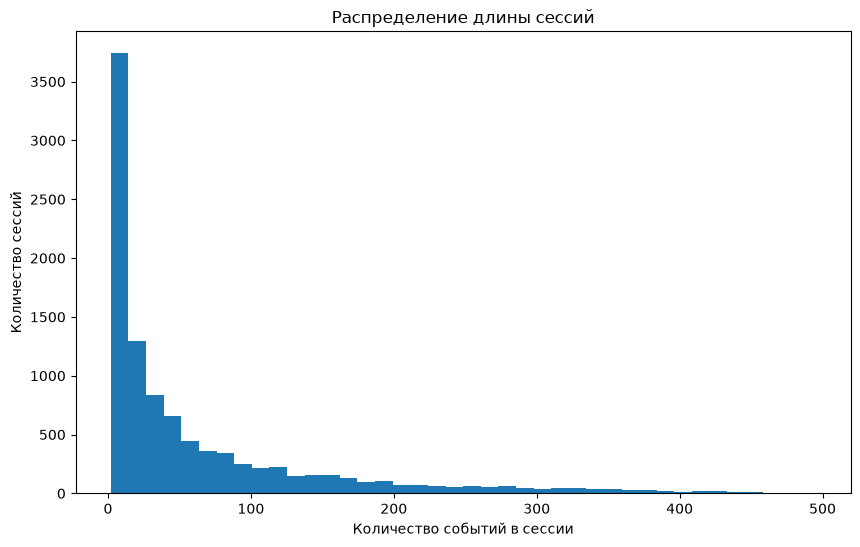

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(session_lengths, bins=40)

plt.xlabel('Количество событий в сессии')
plt.ylabel('Количество сессий')
plt.title('Распределение длины сессий')

plt.show()

### Доля коротких сессий

Распределение имеет выраженный правый хвост: большинство сессий в выборке относительно короткие, но и встречаются сессии с парой сотен событий в сессии. Для дальнейшего анализа посчитаем долю с сессий, с которыми было наибольшее число взаимодействий.

In [28]:
for threshold in [2, 5, 10, 20]:
    share = (session_lengths <= threshold).mean()
    print(f'Сессии ≤ {threshold} событий: {share:.2%}')

Сессии ≤ 2 событий: 6.12%
Сессии ≤ 5 событий: 18.91%
Сессии ≤ 10 событий: 30.94%
Сессии ≤ 20 событий: 44.97%


### Вывод по длине сессий

Распределение длины сессий имеет выраженную правостороннюю асимметрию. Медианная длина составляет 26 событий, при этом средняя — около 63 событий.

Короткие сессии составляют значительную часть выборки: около 31% сессий содержат не более 10 событий, а около 45% — не более 20. 

При построении рекомендательной системы важно будет учесть объем доступной истории взаимодействий и оценить качество рекомендаций для сессий, в зависимости от их длины.

### Повторные взаимодействия с товарами

Стоит проверить, как часто пользователи возвращаются к товару.

In [29]:
session_stats = events.groupby('session').agg(
    events_count=('aid', 'size'),
    unique_items=('aid', 'nunique')
)

session_stats['repeat_share'] = (
    1 - session_stats['unique_items'] / session_stats['events_count']
)

session_stats.describe()

,events_count,unique_items,repeat_share
count,10000.000000,10000.000000,10000.000000
mean,62.874700,35.826000,0.334017
std,85.291679,46.722761,0.200459
min,2.000000,1.000000,0.000000
25%,8.000000,5.000000,0.200000
50%,26.000000,16.000000,0.347186
75%,81.000000,47.000000,0.479738
max,495.000000,331.000000,0.982143


### Вывод по повторным взаимодействиям

Повторные взаимодействия с товарами занимают существенную часть истории сессий. Из данных описательной статистики медианная доля повторных события ~35%, а для 25% cессий она превышает показатель в 48%. 

Из этого делаем вывод, что повторные взаимодействия не стоит сразу удалять, потому что они могут использоваться как признаки заинтересованности пользователя, что крайне полезно при построении рекомендательной системы.

## Анализ популярности товаров

Исследуем распределение количества взаимодействий между товарами и определим, насколько события сконцентрированы вокруг небольшой группы популярных товаров.

In [30]:
item_events = events['aid'].value_counts()

item_events.describe()

count    187648.000000
mean          3.350673
std           6.956713
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max         437.000000
Name: count, dtype: float64

### Концентрация взаимодействий среди популярных товаров

Оценим, какую долю всех событий приходится на наиболее популярные товары. Это позволит понять, насколько взаимодействия пользователей сконцентрированы вокруг небольшой части каталога.

In [31]:
total_events = item_events.sum()

for top_n in [10, 100, 1000, 10000]:
    share = item_events.head(top_n).sum() / total_events
    print(f'Tоп-{top_n}: {share:.2%} всех взаимодействий')

Tоп-10: 0.48% всех взаимодействий
Tоп-100: 2.60% всех взаимодействий
Tоп-1000: 10.99% всех взаимодействий
Tоп-10000: 36.19% всех взаимодействий


Дополнительно оценим долю товаров, которые встретились в исследуемой выборке только один раз.

In [32]:
single_event_share = (item_events == 1).mean()

print(f'Товары с одним взаимодействием: {single_event_share:.2%}')

Товары с одним взаимодействием: 50.74%


### Вывод по популярности товаров

Распределение взаимодействий между товарами имеет выраженный длинный хвост. Около 51% товаров встретились в исследуемой выборке только один раз, тогда как небольшая группа популярных товаров аккумулирует заметную долю взаимодействий: на Top-1 000 приходится около 11% событий, а на Top-10 000 — около 36%.

Популярные товары могут служить простым источником кандидатов, однако использование только популярности приведёт к недостаточному покрытию большого числа редко встречающихся товаров.

## Анализ товаров по типам взаимодействий

Исследуем, как товары представлены в кликах, добавлениях в корзину и заказах. Отдельно проверим, насколько пересекаются множества товаров между различными типами событий.

In [33]:
items_by_type = events.groupby('type')['aid'].nunique()

items_by_type

type
carts      30211
clicks    185350
orders      9854
Name: aid, dtype: int64

### Пересечение товаров между типами взаимодействий

Проверим, насколько пересекаются множества товаров, встречающихся в кликах, добавлениях в корзину и заказах (рассматриваем наличие товаров среди разных типов событий во всей выборке, а не прохождение воронки внутри одной конкретной сессии).

In [34]:
click_items = set(events.loc[events['type'] == 'clicks', 'aid'])
cart_items = set(events.loc[events['type'] == 'carts', 'aid'])
order_items = set(events.loc[events['type'] == 'orders', 'aid'])

print('Clicks ∩ Carts:', len(click_items & cart_items))
print('Clicks ∩ Orders:', len(click_items & order_items))
print('Carts ∩ Orders:', len(cart_items & order_items))
print('Clicks ∩ Carts ∩ Orders:', len(click_items & cart_items & order_items))

Clicks ∩ Carts: 28291
Clicks ∩ Orders: 9102
Carts ∩ Orders: 8549
Clicks ∩ Carts ∩ Orders: 8175


### Типы взаимодействий с товаром внутри одной сессии

Определим, какие типы товаров просходили с одним конкретным товаром внутри одной сессии.

In [35]:
session_item_types = (
    events.groupby(['session', 'aid'])['type'].nunique()
)

session_item_types.value_counts().sort_index()

type
1    323447
2     26407
3      8406
Name: count, dtype: int64

### Вывод по типам взаимодействий

Большая часть пар (session, aid) содержат один уникальный тип взаимодействия - таких около 90%. ~7% содержат два типа и три типа встречается в ~2% случаев. Из этих данных делаем вывод, что большинство взаимодействий товаров ограничивается только одним типом события, но присутствует и заметная группа случаев, которая проходит все три этапа (clicks, carts, orders). Это стоит учитывать при дальнейшем ранжировании кандидатов.

# Итоговые выводы EDA

В ходе разведочного анализа данных (EDA) были выявлены следующие особенности:

- Данные представлены последовательностями событий внутри сессий. Информация о пользователях отсутствует, поэтому персонализация будет строиться на основе текущей сессии, а не долгосрочной истории пользователя.
- События внутри исследованных сессий расположены в хронологическом порядке, что позволяет использовать прошлые взаимодействия для предсказания последующих.
- Распределение типов событий сильно несбалансировано: около 91% событий составляют клики, около 7% — добавления в корзину и около 2% — заказы.
- Длины сессий имеют выраженное правостороннее распределение. Около 31% сессий содержат не более 10 событий, а около 45% — не более 20. Поэтому качество рекомендаций имеет смысл отдельно анализировать для коротких и длинных сессий.
- Повторные взаимодействия с товарами распространены: медианная доля повторных событий составляет около 35%. Поэтому повторные действия не следует удалять автоматически — частота и давность взаимодействия могут стать полезными признаками.
- Популярность товаров имеет длинный хвост: около 51% встретившихся товаров наблюдаются только один раз, тогда как наиболее популярные товары концентрируют заметную часть взаимодействий. Это делает популярность полезным baseline и потенциальным источником кандидатов, но одной популярности недостаточно для покрытия каталога.
- Около 90% пар (session, aid) содержат только один тип взаимодействия, около 7% — два типа и около 2% — все три типа. Тип взаимодействия с товаром потенциально содержит дополнительный сигнал о заинтересованности пользователя.

Полученные наблюдения будут использованы при построении рекомендательной системы и обучения модели.